In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cols = ['ts', 'next_ts', 'ttl', 'create_ts', 'freq', 'last_ts', 'update_ts', 'revals', 'good_rv', 'bad_rv', 'mime', 'size']
dfs = [pd.read_csv(f'../traces/expiry/r5cf_{c}.csv.zst', names=cols, skiprows=lambda i: random.random() > 0.2) for c in ['a', 'c', 'e', 'g']]
df = pd.concat(dfs)
df

,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime,size
0,10,0,6,3,1,3,3,0,0,0,6,608
1,12,0,6,5,1,5,5,0,0,0,6,602
2,12,17,7,4,2,10,4,0,0,0,3,939
3,14,15,1,12,1,12,12,0,0,0,3,3224
4,17,17,10,6,2,11,6,0,0,0,3,1723
...,...,...,...,...,...,...,...,...,...,...,...,...
7353987,2764788,0,43200,2721586,1,2721586,2721586,255231,255229,0,19,2102
7353988,2764788,0,43200,2721587,1,2721587,2721587,255231,255229,0,19,320
7353989,2764789,0,43200,2721588,1,2721588,2721588,255231,255229,0,19,10218
7353990,2764797,0,30,2764761,1,2764761,2764761,468011,468011,0,29,1179874


# feature engineering

In [3]:
def calc_features(df):
    df['should_reval'] = (df['ts'] <= df['next_ts']) & (df['next_ts'] <= (df['ts'] + df['ttl'])) & (df['ttl'] < 7 * 86400)
    df['generations'] = ((df['ts'] - df['create_ts'] - 1) / df['ttl']).round()
    df['t_since_last'] = df['ts'] - df['last_ts']
    df['t_since_last_frac'] = (df['t_since_last'] - 1)/ df['ttl']
    return df

calc_features(df)

,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime,size,should_reval,generations,t_since_last,t_since_last_frac
0,10,0,6,3,1,3,3,0,0,0,6,608,False,1.0,7,1.000000
1,12,0,6,5,1,5,5,0,0,0,6,602,False,1.0,7,1.000000
2,12,17,7,4,2,10,4,0,0,0,3,939,True,1.0,2,0.142857
3,14,15,1,12,1,12,12,0,0,0,3,3224,True,1.0,2,1.000000
4,17,17,10,6,2,11,6,0,0,0,3,1723,True,1.0,6,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7353987,2764788,0,43200,2721586,1,2721586,2721586,255231,255229,0,19,2102,False,1.0,43202,1.000023
7353988,2764788,0,43200,2721587,1,2721587,2721587,255231,255229,0,19,320,False,1.0,43201,1.000000
7353989,2764789,0,43200,2721588,1,2721588,2721588,255231,255229,0,19,10218,False,1.0,43201,1.000000
7353990,2764797,0,30,2764761,1,2764761,2764761,468011,468011,0,29,1179874,False,1.0,36,1.166667


# training

In [4]:
from sklearn.model_selection import train_test_split
import skl2onnx
from skl2onnx.common.data_types import FloatTensorType
import pickle
import math
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler

def split_xy(df):
    y = df['should_reval']
    x = df[['ttl', 'freq', 'generations',
            't_since_last', 't_since_last_frac', 'mime', 'size']]
    return x, y


x, y = split_xy(df)
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.33, random_state = 42)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.33, random_state=42)

x_train_under, y_train_under = RandomUnderSampler(random_state=42).fit_resample(x_train, y_train) # type: ignore
x_train_over, y_train_over = RandomOverSampler(random_state=42).fit_resample(x_train, y_train) # type: ignore

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

def make_rfc(xt, yt):
    rfc = RandomForestClassifier(n_estimators=32, criterion = 'gini', min_samples_leaf = 1 / 2000, random_state=42, n_jobs=-1)
    rfc.fit(xt, yt)
    y_pred = rfc.predict(x_test)
    print(f'Train acc: {accuracy_score(yt, rfc.predict(xt)):0.4f}')
    print(f'Test acc: {accuracy_score(y_test, y_pred):0.4f}')
    gini = pd.Series(rfc.feature_importances_, index=xt.columns).sort_values(ascending=False)
    display(gini)
    print(classification_report(y_test, y_pred))
    return rfc

rfc_base = make_rfc(x_train, y_train)
rfc_over = make_rfc(x_train_over, y_train_over)
rfc_under = make_rfc(x_train_under, y_train_under)


Train acc: 0.8915
Test acc: 0.8916


t_since_last_frac    0.323858
generations          0.298138
freq                 0.162191
ttl                  0.082435
t_since_last         0.066031
mime                 0.042950
size                 0.024397
dtype: float64

              precision    recall  f1-score   support

       False       0.91      0.96      0.93   8020228
        True       0.78      0.62      0.69   1926979

    accuracy                           0.89   9947207
   macro avg       0.85      0.79      0.81   9947207
weighted avg       0.89      0.89      0.89   9947207

Train acc: 0.8442
Test acc: 0.8549


t_since_last_frac    0.327649
generations          0.238702
freq                 0.153611
ttl                  0.092889
mime                 0.083107
t_since_last         0.072199
size                 0.031844
dtype: float64

              precision    recall  f1-score   support

       False       0.95      0.86      0.91   8020228
        True       0.59      0.83      0.69   1926979

    accuracy                           0.85   9947207
   macro avg       0.77      0.84      0.80   9947207
weighted avg       0.88      0.85      0.86   9947207

Train acc: 0.8443
Test acc: 0.8524


t_since_last_frac    0.340008
generations          0.233854
freq                 0.152333
ttl                  0.096954
mime                 0.077875
t_since_last         0.068446
size                 0.030530
dtype: float64

              precision    recall  f1-score   support

       False       0.95      0.86      0.90   8020228
        True       0.58      0.83      0.69   1926979

    accuracy                           0.85   9947207
   macro avg       0.77      0.84      0.79   9947207
weighted avg       0.88      0.85      0.86   9947207



AUC: 0.9239, AP: 0.7878
AUC: 0.9241, AP: 0.7889
AUC: 0.9240, AP: 0.7884


<Figure size 1400x500 with 0 Axes>

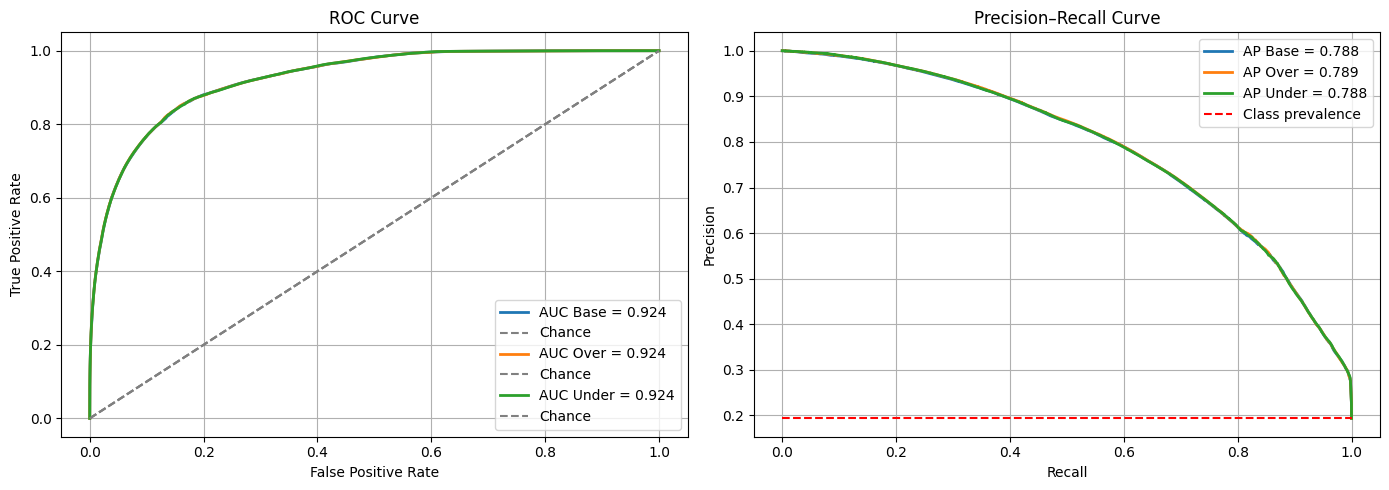

In [6]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(14, 5))

rfcs = [("Base", rfc_base), ("Over", rfc_over), ("Under", rfc_under)]
for name, rfc in rfcs:
    y_scores = rfc.predict_proba(x_test)[:, 1]
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_scores)
    auc_value = roc_auc_score(y_test, y_scores)
    precision, recall, pr_thresholds = precision_recall_curve(y_test, y_scores)
    ap_value = average_precision_score(y_test, y_scores)
    print(f"AUC: {auc_value:.4f}, AP: {ap_value:.4f}")

    ax1.plot(fpr, tpr, linewidth=2, label=f"AUC {name} = {auc_value:.3f}")
    ax1.plot([0,1], [0,1], '--', color='gray', label="Chance")
    ax1.set_title("ROC Curve")
    ax2.plot(recall, precision, linewidth=2, label=f"AP {name} = {ap_value:.3f}")

ax1.legend()
ax1.grid(True)
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax2.hlines(y_test.mean(), 0, 1, colors='red', linestyles='--', label="Class prevalence")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

In [8]:
import os

def save_model(m, name):
    with open(f'../models/{name}.pkl', 'wb') as f:
        pickle.dump(m, f)

    onnx = skl2onnx.to_onnx(
        m,
        initial_types=[('in', FloatTensorType([None, x_train.shape[1]]))],  # type: ignore
        options={'zipmap': False},
        verbose=1)
    with open(f'../models/{name}.onnx', 'wb') as f:
        f.write(onnx.SerializeToString())  # type: ignore

    print(f'ONNX model size: {os.path.getsize(f"../models/{name}.onnx") / 1024:.2f} KB')

save_model(rfc_base, 'rfc_cf_v5-base')
save_model(rfc_over, 'rfc_cf_v5-over')
save_model(rfc_under, 'rfc_cf_v5-under')

[to_onnx] initial_types=[('in', FloatTensorType(shape=[None, 7]))]
[convert_sklearn] parse_sklearn_model


[convert_sklearn] convert_topology
[convert_operators] begin
[convert_operators] iteration 1 - n_vars=0 n_ops=1
[call_converter] call converter for 'SklearnRandomForestClassifier'.
[convert_operators] end iter: 1 - n_vars=3
[convert_operators] iteration 2 - n_vars=3 n_ops=1
[convert_operators] end iter: 2 - n_vars=3
[convert_operators] end.
[_update_domain_version] +opset 0: name='ai.onnx.ml', version=1
[convert_topology] +opset: name='', version=21
[convert_sklearn] end
ONNX model size: 1006.02 KB
[to_onnx] initial_types=[('in', FloatTensorType(shape=[None, 7]))]
[convert_sklearn] parse_sklearn_model
[convert_sklearn] convert_topology
[convert_operators] begin
[convert_operators] iteration 1 - n_vars=0 n_ops=1
[call_converter] call converter for 'SklearnRandomForestClassifier'.
[convert_operators] end iter: 1 - n_vars=3
[convert_operators] iteration 2 - n_vars=3 n_ops=1
[convert_operators] end iter: 2 - n_vars=3
[convert_operators] end.
[_update_domain_version] +opset 0: name='ai.onnx

In [ ]:
# from sklearn.neural_network import MLPClassifier

# mlp = MLPClassifier(hidden_layer_sizes=(16, 32, 32, 16), max_iter=200, early_stopping=True, random_state=42)
# mlp.fit(x_train, y_train)

# y_pred = mlp.predict(x_test)
# print(f'Train acc: {accuracy_score(y_train, mlp.predict(x_train)):0.4f}')
# print(f'Test acc: {accuracy_score(y_test, y_pred):0.4f}')
# print(classification_report(y_test, y_pred))

In [ ]:
import pickle
rfc_base = pickle.load(open('../models/rfc_cf_all_v5-base.pkl', 'rb'))
rfc_over = pickle.load(open('../models/rfc_cf_all_v5-over.pkl', 'rb'))
rfc_under = pickle.load(open('../models/rfc_cf_all_v5-under.pkl', 'rb'))

display(rfc_base.predict_proba(x_test[:5]))
display(rfc_over.predict_proba(x_test[:5]))
display(rfc_under.predict_proba(x_test[:5]))

FileNotFoundError: [Errno 2] No such file or directory: '../models/rfc_cf_all_v5-base.pkl'

# transferability

In [ ]:
for subdf in dfs:
    subdf = calc_features(subdf)
    x, y = split_xy(subdf)
    y_pred = rfc.predict(x)
    acc = accuracy_score(y, y_pred)
    print(f'CF acc: {acc:0.4f}')
    print(classification_report(y, y_pred))


CF acc: 0.9927
              precision    recall  f1-score   support

       False       1.00      0.99      1.00   5464293
        True       0.95      1.00      0.98    916643

    accuracy                           0.99   6380936
   macro avg       0.98      1.00      0.99   6380936
weighted avg       0.99      0.99      0.99   6380936

CF acc: 0.9932
              precision    recall  f1-score   support

       False       1.00      0.99      1.00   9675808
        True       0.91      1.00      0.95    668582

    accuracy                           0.99  10344390
   macro avg       0.95      1.00      0.97  10344390
weighted avg       0.99      0.99      0.99  10344390

CF acc: 0.9959
              precision    recall  f1-score   support

       False       1.00      1.00      1.00   5225187
        True       0.97      1.00      0.99    838395

    accuracy                           1.00   6063582
   macro avg       0.99      1.00      0.99   6063582
weighted avg       1.00      

In [ ]:
dffbtest = pd.read_csv(f'../traces/expiry/fb_a.csv.zst', names=cols, nrows=1000)
dffbtest = calc_features(dffbtest)
dffbtest.head()

FileNotFoundError: [Errno 2] No such file or directory: '../traces/expiry/fb_a.csv.zst'

In [ ]:
for c in ['a', 'b', 'c']:
    dfs = pd.read_csv(f'../traces/expiry/fb_{c}.csv.zst', names=cols, skiprows = lambda i : i > 0 and random.random() > 0.005)
    dfs = calc_features(dfs)
    dfs = dfs[dfs['ttl'] != 0]
    x, y = split_xy(dfs)
    y_pred = rfc.predict(x)
    acc = accuracy_score(y, y_pred)
    print(f'CF {c} acc: {acc:0.4f}')
    print(classification_report(y, y_pred))

CF a acc: 0.9576
              precision    recall  f1-score   support

       False       0.99      0.97      0.98    119579
        True       0.16      0.39      0.23      1983

    accuracy                           0.96    121562
   macro avg       0.58      0.68      0.60    121562
weighted avg       0.98      0.96      0.97    121562

CF b acc: 0.9639
              precision    recall  f1-score   support

       False       0.99      0.97      0.98    355956
        True       0.15      0.41      0.22      4391

    accuracy                           0.96    360347
   macro avg       0.57      0.69      0.60    360347
weighted avg       0.98      0.96      0.97    360347

CF c acc: 0.9779
              precision    recall  f1-score   support

       False       1.00      0.98      0.99    295739
        True       0.18      0.54      0.27      2296

    accuracy                           0.98    298035
   macro avg       0.59      0.76      0.63    298035
weighted avg       0.99

In [ ]:
dfwm = pd.read_csv(f'../traces/expiry/wm_t.csv.zst', names=cols, skiprows = lambda i : i > 0 and random.random() > 0.002)
dfwm = calc_features(dfwm)
dfwm = dfwm[dfwm['ttl'] != 0]
x, y = split_xy(dfwm)
y_pred = rfc.predict(x)
acc = accuracy_score(y, y_pred)
print(f'CF {c} acc: {acc:0.4f}')
print(classification_report(y, y_pred))

CF c acc: 0.7603
              precision    recall  f1-score   support

       False       0.87      0.70      0.78     56623
        True       0.66      0.85      0.74     39056

    accuracy                           0.76     95679
   macro avg       0.77      0.77      0.76     95679
weighted avg       0.78      0.76      0.76     95679

